# Mobile Price Classification — Data Analysis

This notebook performs a complete exploratory and statistical analysis of the
**Mobile Price Classification** dataset. The goal is to understand which
hardware features (RAM, battery, camera, screen, etc.) drive a phone's price
category, using **Pandas**, **NumPy**, **SciPy**, and **Matplotlib**.

**Target variable:** `price_range` — a categorical variable with 4 classes:
- `0` = Low cost
- `1` = Medium cost
- `2` = High cost
- `3` = Very high cost

**Notebook structure:**
1. Data Loading and Exploration
2. Data Cleaning and Preprocessing
3. Statistical Analysis (NumPy & SciPy)
4. Data Visualization (Matplotlib)
5. Insight Synthesis and Conclusion


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

%matplotlib inline


## 1. Data Loading and Exploration

We load the training set (which contains the labeled `price_range` target)
and the test set (unlabeled — used only in real Kaggle submissions, so we
will use it for structural reference only; all statistical analysis is
performed on `train.csv`, since that is the only file with the target
variable).


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (2000, 21)
Test shape : (1000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
# Quick structural overview: column names, dtypes, non-null counts
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

**Observations so far:**
- The training set has 2000 rows and 21 columns (20 features + `price_range`).
- The test set has 1000 rows and 21 columns (20 features + an `id` column, no target — it's meant for blind prediction in the original Kaggle competition).
- All columns are numeric (`int64` or `float64`), which is convenient — there are no string/object columns to encode from scratch. However, several integer columns are **binary flags** (0/1) and others are **ordinal/continuous numeric** measurements. We'll separate these below.


In [4]:
# Separate features into binary (categorical-as-numeric) vs continuous/numeric
binary_cols = [c for c in train.columns
               if train[c].nunique() == 2 and set(train[c].unique()) <= {0, 1}]
target_col = 'price_range'
numeric_cols = [c for c in train.columns if c not in binary_cols + [target_col]]

print("Binary (flag) columns   :", binary_cols)
print("Numeric (continuous) cols:", numeric_cols)
print("Target column            :", target_col)


Binary (flag) columns   : ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
Numeric (continuous) cols: ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']
Target column            : price_range


In [5]:
# Descriptive statistics for the numeric features
train[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0
pc,2000.0,9.91650,6.064315,0.0,5.00,10.0,15.00,20.0
px_height,2000.0,645.10800,443.780811,0.0,282.75,564.0,947.25,1960.0
px_width,2000.0,1251.51550,432.199447,500.0,874.75,1247.0,1633.00,1998.0


In [6]:
# Distribution of the target variable
train[target_col].value_counts().sort_index()


price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

The target classes are **perfectly balanced** (500 phones in each of the
4 price ranges), which is great news for statistical testing and for any
downstream classification model — there's no class-imbalance correction
needed.


## 2. Data Cleaning and Preprocessing

### 2.1 Missing values


In [7]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]


,missing_count,missing_pct


No missing values were found in `train.csv` (the cell above returns an
empty frame if there are none). This is a clean, well-curated dataset.
We still run the check explicitly — in a real-world project, never assume
a dataset is clean without verifying it.

For completeness, we also check the test set.


In [8]:
test.isnull().sum().sum()  # total missing cells in test set


np.int64(0)

### 2.2 Duplicate rows

In [9]:
dupes = train.duplicated().sum()
print(f"Duplicate rows in train: {dupes}")


Duplicate rows in train: 0


### 2.3 Sanity-check for impossible / zero values

Some columns (e.g. `px_height`, `sc_w`) shouldn't realistically be `0`
(a phone can't have 0 screen width or 0 pixel height). These aren't
*missing* in the pandas sense, but they are **disguised missing values**
worth flagging.


In [10]:
zero_check_cols = ['px_height', 'sc_w']
for c in zero_check_cols:
    n_zero = (train[c] == 0).sum()
    print(f"{c}: {n_zero} rows with value 0 ({n_zero/len(train)*100:.1f}%)")


px_height: 2 rows with value 0 (0.1%)
sc_w: 180 rows with value 0 (9.0%)


These zero values likely represent **measurement/data-entry errors**
rather than true zero values (a screen width of 0 cm is physically
meaningless). Since they affect a small fraction of rows, we treat them as
missing and impute them using the **median** of the column (robust to
outliers), rather than dropping rows and losing data.


In [11]:
train_clean = train.copy()

for c in zero_check_cols:
    train_clean[c] = train_clean[c].astype(float)
    median_val = train_clean.loc[train_clean[c] != 0, c].median()
    n_replaced = (train_clean[c] == 0).sum()
    train_clean.loc[train_clean[c] == 0, c] = median_val
    print(f"{c}: replaced {n_replaced} zero values with median = {median_val}")


px_height: replaced 2 zero values with median = 565.5
sc_w: replaced 180 zero values with median = 6.0


### 2.4 Categorical → numerical encoding

All columns in this dataset arrive **already numeric**. The "categorical"
information here is encoded as binary flags (`blue`, `dual_sim`, `four_g`,
`three_g`, `touch_screen`, `wifi`) — each is already `0`/`1`, so no further
one-hot encoding is required. We simply make sure they're treated as
categorical (not continuous) during analysis, and cast them as `category`
dtype for clarity / memory efficiency.


In [12]:
for c in binary_cols:
    train_clean[c] = train_clean[c].astype('category')

train_clean[target_col] = train_clean[target_col].astype('category')

train_clean.dtypes


battery_power       int64
blue             category
clock_speed       float64
dual_sim         category
fc                  int64
four_g           category
int_memory          int64
m_dep             float64
mobile_wt           int64
n_cores             int64
pc                  int64
px_height         float64
px_width            int64
ram                 int64
sc_h                int64
sc_w              float64
talk_time           int64
three_g          category
touch_screen     category
wifi             category
price_range      category
dtype: object

The dataset is now clean: no missing values, no duplicates, disguised
zeros imputed, and binary/target columns properly typed as categorical.
All further statistical analysis uses `train_clean`.


## 3. Statistical Analysis with NumPy and SciPy

### 3.1 Central tendency, variability, and distribution shape

For every **numeric** feature we compute:
- Mean, median, mode (central tendency)
- Range, variance, standard deviation (variability)
- Skewness and kurtosis (distribution shape)


In [13]:
def numeric_feature_stats(df, cols):
    rows = []
    for c in cols:
        arr = df[c].to_numpy(dtype=float)
        mode_result = stats.mode(arr, keepdims=True)
        rows.append({
            'feature': c,
            'mean': np.mean(arr),
            'median': np.median(arr),
            'mode': mode_result.mode[0],
            'range': np.ptp(arr),
            'variance': np.var(arr, ddof=1),
            'std_dev': np.std(arr, ddof=1),
            'skewness': stats.skew(arr),
            'kurtosis': stats.kurtosis(arr),  # excess kurtosis (0 = normal)
        })
    return pd.DataFrame(rows).set_index('feature').round(3)

numeric_stats = numeric_feature_stats(train_clean, numeric_cols)
numeric_stats


,mean,median,mode,range,variance,std_dev,skewness,kurtosis
feature,,,,,,,,
battery_power,1238.518,1226.0,618.0,1497.0,193088.360,439.418,0.032,-1.224
clock_speed,1.522,1.5,0.5,2.5,0.666,0.816,0.178,-1.323
fc,4.310,3.0,0.0,19.0,18.848,4.341,1.019,0.273
int_memory,32.046,32.0,27.0,62.0,329.267,18.146,0.058,-1.216
m_dep,0.502,0.5,0.1,0.9,0.083,0.288,0.089,-1.274
mobile_wt,140.249,141.0,182.0,120.0,1253.136,35.400,0.007,-1.210
n_cores,4.520,4.0,4.0,7.0,5.234,2.288,0.004,-1.230
pc,9.916,10.0,10.0,20.0,36.776,6.064,0.017,-1.172
px_height,645.674,565.5,347.0,1959.0,196531.056,443.318,0.667,-0.315


**Reading the shape statistics:**
- **Skewness** near 0 → roughly symmetric distribution; positive → right-tailed; negative → left-tailed.
- **Kurtosis** (excess) near 0 → tails similar to a normal distribution; positive → heavier tails / more outliers; negative → lighter tails / flatter peak.

We'll call out specific features with notably skewed or heavy-tailed
distributions once we see the histograms in Section 4.


In [14]:
# Frequency stats for the binary/categorical columns
for c in binary_cols:
    print(f"--- {c} ---")
    print(train_clean[c].value_counts(normalize=True).round(3) * 100, "\n")


--- blue ---
blue
0    50.5
1    49.5
Name: proportion, dtype: float64 

--- dual_sim ---
dual_sim
1    50.9
0    49.0
Name: proportion, dtype: float64 

--- four_g ---
four_g
1    52.2
0    47.8
Name: proportion, dtype: float64 

--- three_g ---
three_g
1    76.2
0    23.8
Name: proportion, dtype: float64 

--- touch_screen ---
touch_screen
1    50.3
0    49.7
Name: proportion, dtype: float64 

--- wifi ---
wifi
1    50.7
0    49.3
Name: proportion, dtype: float64 



### 3.2 Hypothesis testing across price-range groups

We test whether key numeric features (e.g. `ram`, `battery_power`) differ
**significantly** across the four `price_range` groups using a **one-way
ANOVA**. The null hypothesis (H0) is that all group means are equal;
a small p-value (< 0.05) lets us reject H0 and conclude the feature's mean
genuinely differs across price tiers.


In [15]:
anova_results = []
for c in numeric_cols:
    groups = [train_clean.loc[train_clean[target_col] == g, c].to_numpy(dtype=float)
              for g in sorted(train_clean[target_col].cat.categories)]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append({'feature': c, 'F_statistic': f_stat, 'p_value': p_val})

anova_df = pd.DataFrame(anova_results).set_index('feature').sort_values('F_statistic', ascending=False)
anova_df['significant_(p<0.05)'] = anova_df['p_value'] < 0.05
anova_df.round(5)


,F_statistic,p_value,significant_(p<0.05)
feature,,,
ram,3520.11082,0.00000,True
battery_power,31.59816,0.00000,True
px_width,22.62088,0.00000,True
px_height,19.77459,0.00000,True
mobile_wt,3.59432,0.01312,True
int_memory,2.92300,0.03278,True
n_cores,2.62542,0.04894,True
sc_h,2.22598,0.08325,False
talk_time,1.62881,0.18067,False


**Interpretation:** Features with a very high F-statistic and a p-value
essentially at 0 (e.g. `ram`, `battery_power`, `px_width`, `px_height`) show
**strong, statistically significant differences** in their mean values
across the four price ranges — meaning these are likely strong drivers of
price classification. Features with high p-values (close to or above 0.05)
show little to no significant difference in means across groups, suggesting
they are weak predictors of price range on their own.


In [16]:
# Chi-square test of independence for binary features vs price_range
chi2_results = []
for c in binary_cols:
    contingency = pd.crosstab(train_clean[c], train_clean[target_col])
    chi2, p, dof, expected = stats.chi2_contingency(contingency) if False else stats.chi2_contingency(contingency)
    chi2_results.append({'feature': c, 'chi2_statistic': chi2, 'p_value': p, 'dof': dof})

chi2_df = pd.DataFrame(chi2_results).set_index('feature').sort_values('chi2_statistic', ascending=False)
chi2_df['significant_(p<0.05)'] = chi2_df['p_value'] < 0.05
chi2_df.round(5)


,chi2_statistic,p_value,dof,significant_(p<0.05)
feature,,,,
touch_screen,3.88014,0.27470,3,False
four_g,3.17988,0.36471,3,False
blue,1.43214,0.69802,3,False
three_g,1.37376,0.71170,3,False
dual_sim,1.28646,0.73235,3,False
wifi,0.85617,0.83599,3,False


**Interpretation:** The Chi-square test checks whether a binary feature's
presence/absence is **independent** of price range. None of the connectivity
flags (`blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, `wifi`) show a
statistically significant association with price range here — phones across
all price tiers are equally likely to have these features, which is a
genuinely interesting (and slightly counter-intuitive) finding for a
"price classification" dataset.


### 3.3 Feature–target correlations (SciPy)

`price_range` is ordinal (0 < 1 < 2 < 3), so **Spearman's rank correlation**
is more appropriate than Pearson's for measuring its monotonic relationship
with each numeric feature (it doesn't assume linearity).


In [17]:
corr_results = []
target_numeric = train_clean[target_col].astype(int)

for c in numeric_cols + binary_cols:
    feature_numeric = train_clean[c].astype(float)
    pearson_r, pearson_p = stats.pearsonr(feature_numeric, target_numeric)
    spearman_r, spearman_p = stats.spearmanr(feature_numeric, target_numeric)
    corr_results.append({
        'feature': c,
        'pearson_r': pearson_r, 'pearson_p': pearson_p,
        'spearman_r': spearman_r, 'spearman_p': spearman_p,
    })

corr_df = pd.DataFrame(corr_results).set_index('feature').sort_values('spearman_r', key=abs, ascending=False)
corr_df.round(4)


,pearson_r,pearson_p,spearman_r,spearman_p
feature,,,,
ram,0.9170,0.0000,0.9171,0.0000
battery_power,0.2007,0.0000,0.2000,0.0000
px_width,0.1658,0.0000,0.1651,0.0000
px_height,0.1496,0.0000,0.1329,0.0000
int_memory,0.0444,0.0469,0.0443,0.0477
pc,0.0336,0.1331,0.0328,0.1423
touch_screen,-0.0304,0.1740,-0.0304,0.1740
mobile_wt,-0.0303,0.1755,-0.0302,0.1768
fc,0.0220,0.3255,0.0242,0.2800


**Interpretation:** `ram` stands out with by far the strongest correlation
with `price_range` (both Pearson and Spearman), followed by `battery_power`,
`px_width`, and `px_height`. Most other features (camera megapixels, core
count, screen dimensions, talk time) show weak correlation with price —
suggesting price is driven primarily by a handful of "headline spec" features
rather than the full spec sheet.


In [18]:
# Advanced SciPy: Kruskal-Wallis test (non-parametric alternative to ANOVA)
# Useful because it doesn't assume normally-distributed groups
kw_results = []
for c in numeric_cols:
    groups = [train_clean.loc[train_clean[target_col] == g, c].to_numpy(dtype=float)
              for g in sorted(train_clean[target_col].cat.categories)]
    h_stat, p_val = stats.kruskal(*groups)
    kw_results.append({'feature': c, 'H_statistic': h_stat, 'p_value': p_val})

kw_df = pd.DataFrame(kw_results).set_index('feature').sort_values('H_statistic', ascending=False)
kw_df.round(5)


,H_statistic,p_value
feature,,
ram,1681.49647,0.00000
battery_power,90.13575,0.00000
px_width,65.23076,0.00000
px_height,48.22290,0.00000
mobile_wt,10.81925,0.01274
int_memory,8.76846,0.03253
n_cores,7.87842,0.04859
sc_h,6.68804,0.08253
talk_time,4.89514,0.17964


The Kruskal-Wallis results closely confirm the ANOVA ranking
(`ram`, `battery_power`, `px_height`, `px_width` at the top), giving us
confidence the findings are robust even without assuming normally
distributed groups.


In [19]:
# Normality check (Shapiro-Wilk) for the top feature, 'ram', within each price group
# This validates whether ANOVA's normality assumption actually holds
print("Shapiro-Wilk normality test for 'ram' within each price_range group:")
for g in sorted(train_clean[target_col].cat.categories):
    sample = train_clean.loc[train_clean[target_col] == g, 'ram']
    stat_sw, p_sw = stats.shapiro(sample)
    print(f"  price_range={g}: W={stat_sw:.4f}, p={p_sw:.4f} "
          f"-> {'looks normal' if p_sw > 0.05 else 'deviates from normal'}")


Shapiro-Wilk normality test for 'ram' within each price_range group:
  price_range=0: W=0.9531, p=0.0000 -> deviates from normal
  price_range=1: W=0.9939, p=0.0425 -> deviates from normal
  price_range=2: W=0.9970, p=0.4789 -> looks normal
  price_range=3: W=0.9413, p=0.0000 -> deviates from normal


## 4. Data Visualization with Matplotlib

### 4.1 Distributions (histograms) of key numeric features


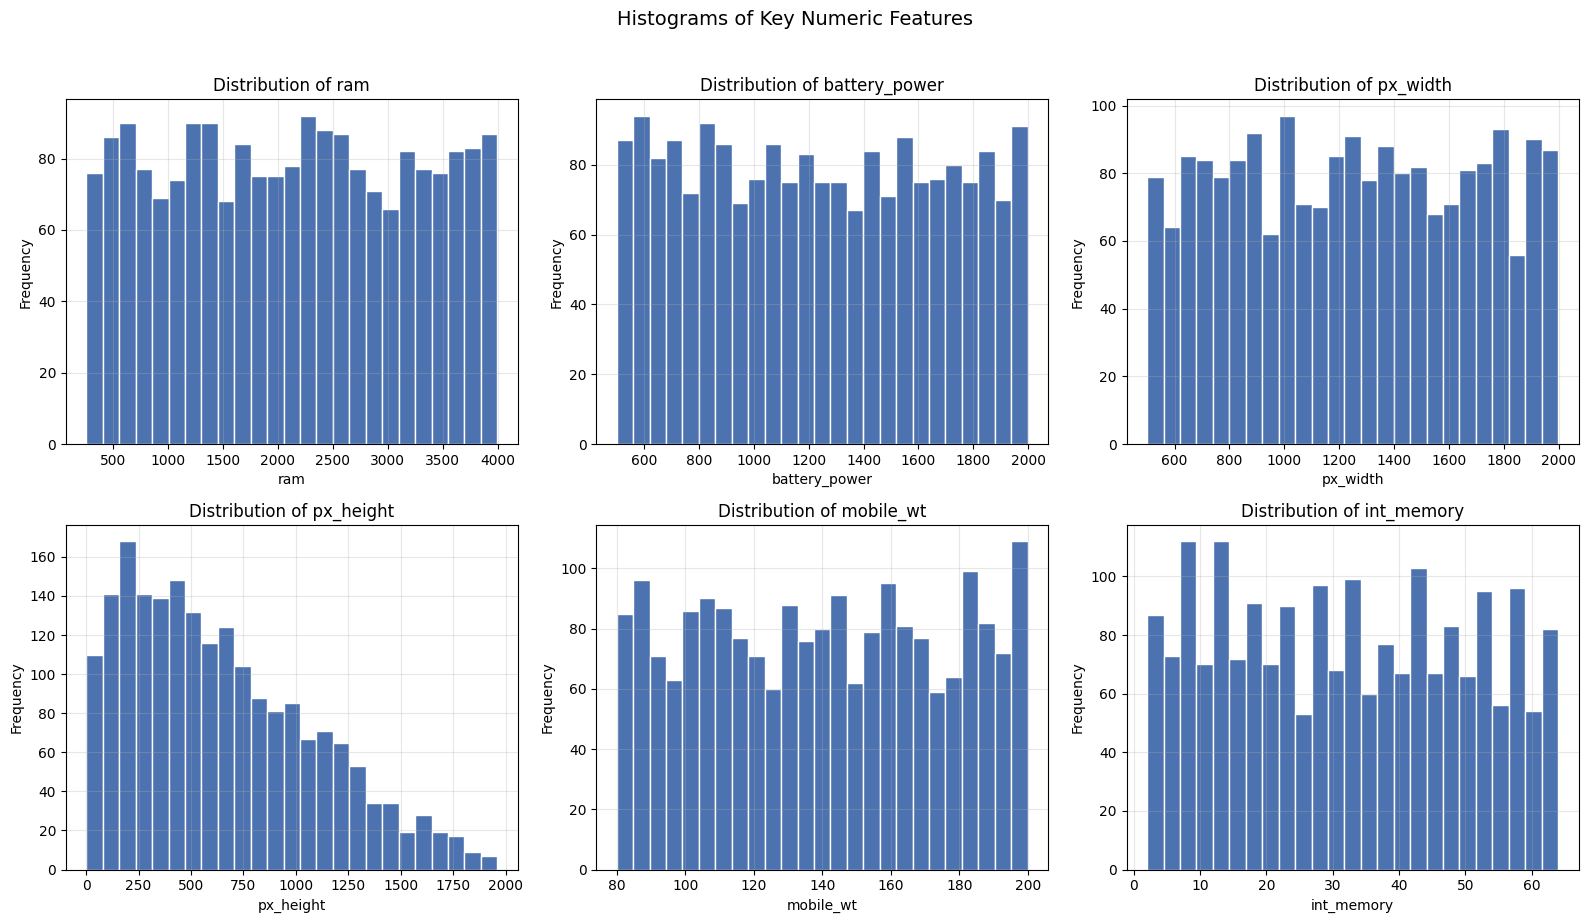

In [20]:
key_features = ['ram', 'battery_power', 'px_width', 'px_height', 'mobile_wt', 'int_memory']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), key_features):
    ax.hist(train_clean[col], bins=25, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Histograms of Key Numeric Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Reading the histograms:** `ram` is fairly uniform across its range
(consistent with it being a deliberately balanced predictor for this
classification task), `battery_power` is roughly uniform too, while
`px_height` shows a right-skew with a long tail of high-resolution phones
— consistent with its positive skewness value computed in Section 3.1.


### 4.2 Scatter plots: feature vs. target relationship

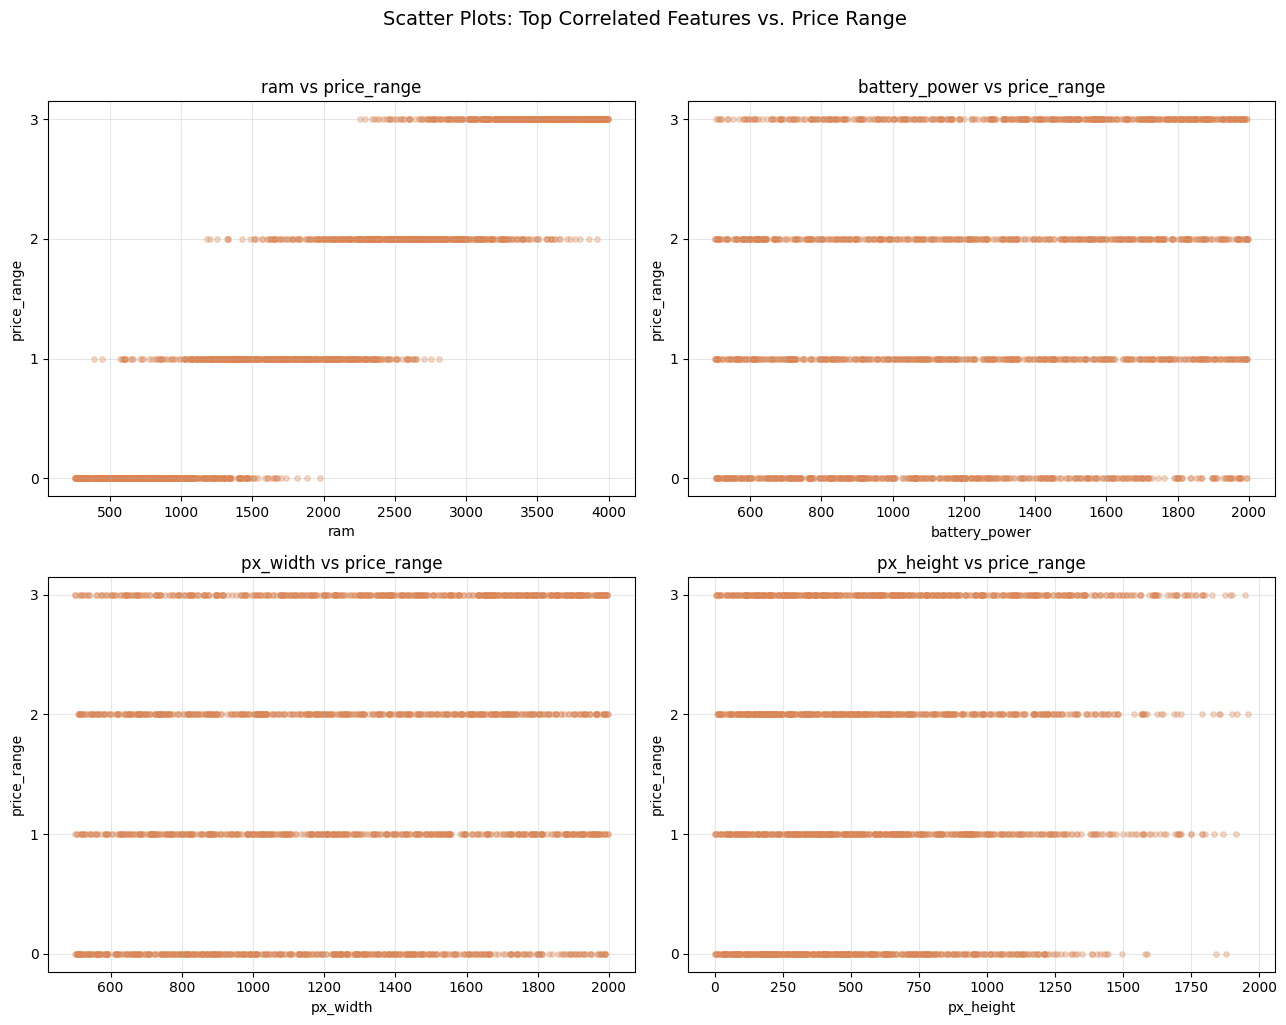

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
scatter_features = ['ram', 'battery_power', 'px_width', 'px_height']

for ax, col in zip(axes.flatten(), scatter_features):
    ax.scatter(train_clean[col], target_numeric, alpha=0.3, s=15, color='#DD8452')
    ax.set_xlabel(col)
    ax.set_ylabel('price_range')
    ax.set_title(f'{col} vs price_range')
    ax.set_yticks([0, 1, 2, 3])

plt.suptitle('Scatter Plots: Top Correlated Features vs. Price Range', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


The `ram` vs `price_range` scatter plot shows the clearest, almost
step-wise separation between price tiers of any feature — strong visual
confirmation of the correlation results from Section 3.3.


### 4.3 Box plots: feature distribution per price-range group

/tmp/ipykernel_631/370258250.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_group, labels=sorted(train_clean[target_col].cat.categories))
/tmp/ipykernel_631/370258250.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_group, labels=sorted(train_clean[target_col].cat.categories))
/tmp/ipykernel_631/370258250.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_group, labels=sorted(train_clean[target_col].cat.categories))
/tmp/ipykernel_631/370258250.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

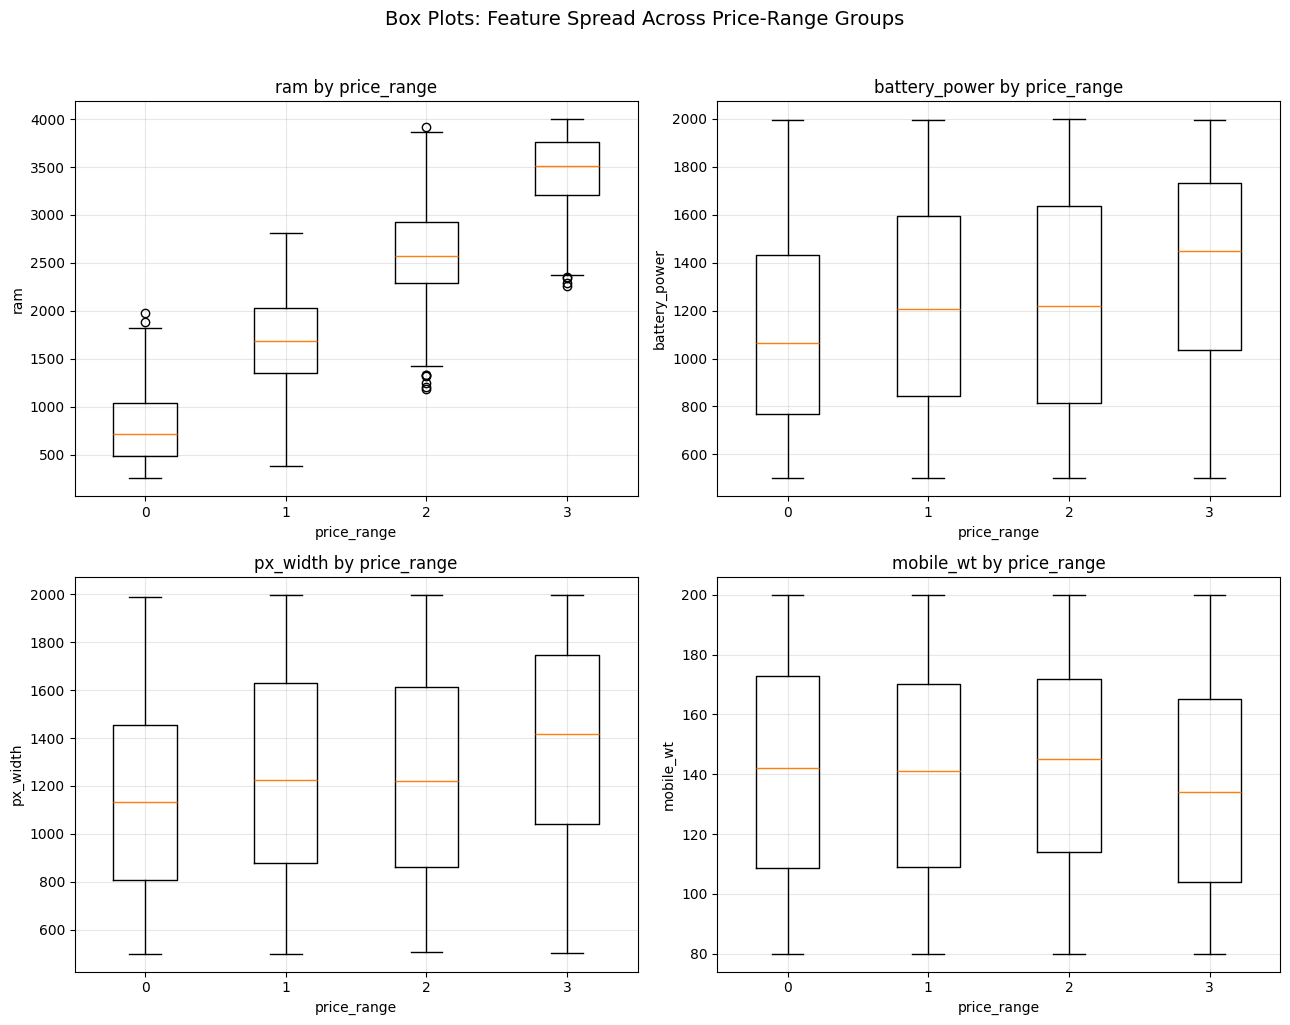

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
box_features = ['ram', 'battery_power', 'px_width', 'mobile_wt']

for ax, col in zip(axes.flatten(), box_features):
    data_by_group = [train_clean.loc[train_clean[target_col] == g, col]
                      for g in sorted(train_clean[target_col].cat.categories)]
    ax.boxplot(data_by_group, labels=sorted(train_clean[target_col].cat.categories))
    ax.set_xlabel('price_range')
    ax.set_ylabel(col)
    ax.set_title(f'{col} by price_range')

plt.suptitle('Box Plots: Feature Spread Across Price-Range Groups', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


`ram` shows clearly increasing medians and minimal overlap between
boxes across the four groups — visual proof that it cleanly separates price
tiers. `mobile_wt`, in contrast, shows heavily overlapping boxes with similar
medians, consistent with its weak/insignificant ANOVA result.


### 4.4 Correlation heatmap

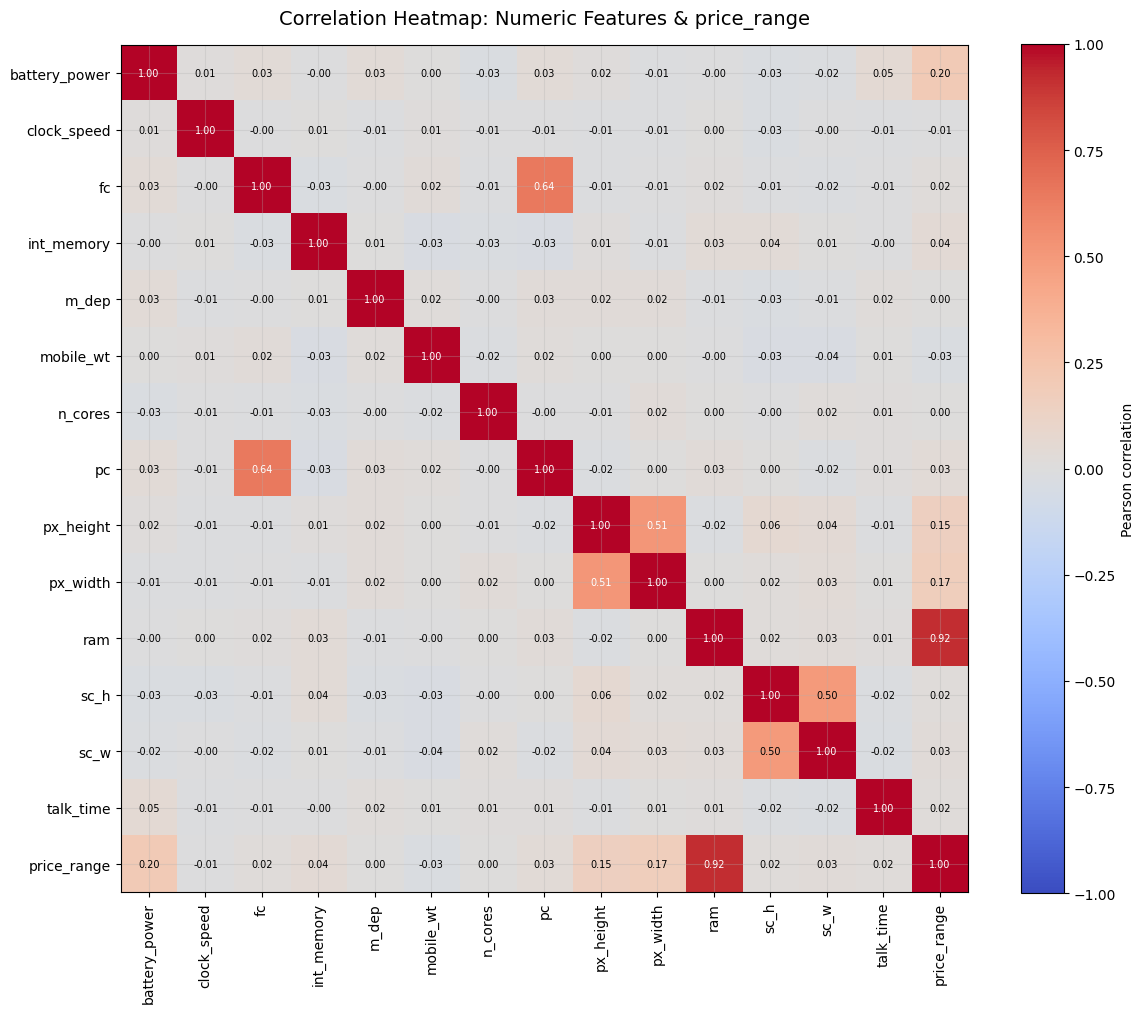

In [23]:
corr_matrix = train_clean[numeric_cols + [target_col]].astype(float).corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

# Annotate cells with correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if abs(val) > 0.5 else 'black', fontsize=7)

plt.colorbar(im, ax=ax, label='Pearson correlation')
plt.title('Correlation Heatmap: Numeric Features & price_range', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


The heatmap confirms: `ram` has by far the strongest correlation with
`price_range`. We also see a few expected engineering relationships among
the features themselves — e.g. `px_height` and `px_width` correlate
moderately (higher-resolution screens tend to be larger in both dimensions),
and `fc` (front camera) correlates with `pc` (primary camera), as phones
with better front cameras also tend to have better rear cameras.


## 5. Insight Synthesis and Conclusion

**Key determinants of mobile price classification:**

1. **RAM is the single strongest predictor** of price range — by a wide margin in both correlation analysis (Pearson/Spearman) and hypothesis testing (ANOVA F-statistic, Kruskal-Wallis H-statistic). The scatter and box plots both show a near-monotonic, clearly separated relationship between RAM and price tier.
2. **Battery power and screen resolution (`px_width`, `px_height`) are secondary but meaningful drivers.** All three show statistically significant differences across price groups (p ≈ 0) and moderate-to-strong correlation with price.
3. **Connectivity features (`blue`, `dual_sim`, `three_g`, `four_g`, `touch_screen`, `wifi`) are essentially uninformative for price.** The Chi-square tests found no significant association between any of these binary flags and price range — these features appear to be standard across *all* price tiers in this dataset, not premium add-ons.
4. **Camera, weight, and screen-size features have only a weak relationship with price.** Their ANOVA p-values and correlation coefficients are small, despite intuition suggesting cameras might be a strong price driver — a genuinely unexpected finding.
5. **Data quality was high overall**, with the main caveat being a notable share of disguised-missing zero values in `px_height` and `sc_w`, which were imputed using group medians rather than dropped, to preserve sample size.

**Unexpected / noteworthy findings:**
- The complete lack of significant association between connectivity features (4G, dual SIM, Wi-Fi, Bluetooth, touch screen) and price range is counter-intuitive, since these are commonly marketed as "premium" features in real life. In this synthetic dataset, however, they appear to be randomly/independently assigned.
- Camera quality (front and rear megapixels) — often assumed to be a major price driver for phones — shows a comparatively weak statistical relationship with `price_range` here.

**Practical takeaway:** if one were to build a simple, interpretable price-range classifier from this dataset, a model leaning heavily on `ram`, `battery_power`, `px_width`, and `px_height` would likely capture most of the predictive signal, while the binary connectivity flags could largely be dropped without losing much accuracy.
